In [ ]:
# Загрузка необходимых библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Для визуализации и предобработки
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.feature_selection import mutual_info_regression

# Для Gain Ratio (используем энтропию через DecisionTree)
from sklearn.metrics import mutual_info_score
import math

# Для игнорирования предупреждений
import warnings
warnings.filterwarnings('ignore')

# Для отображения графиков в Colab
%matplotlib inline

In [ ]:
# Загрузка данных
df = pd.read_csv('/Laptop_price.csv')

# Первые 5 строк
print("Первые 5 строк датасета:")
display(df.head())

# Общая информация о датасете
print("\nИнформация о датасете:")
df.info()

# Описательная статистика для числовых признаков
print("\nОписательная статистика:")
display(df.describe())

# Проверка на пропуски
print("\nКоличество пропусков в каждом столбце:")
print(df.isnull().sum())

Первые 5 строк датасета:


,Brand,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
0,Asus,3.830296,16,512,11.185147,2.641094,17395.093065
1,Acer,2.912833,4,1000,11.311372,3.260012,31607.605919
2,Lenovo,3.241627,4,256,11.853023,2.029061,9291.023542
3,Acer,3.806248,16,512,12.280360,4.573865,17436.728334
4,Acer,3.268097,32,1000,14.990877,4.193472,32917.990718



Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Brand             1000 non-null   object 
 1   Processor_Speed   1000 non-null   float64
 2   RAM_Size          1000 non-null   int64  
 3   Storage_Capacity  1000 non-null   int64  
 4   Screen_Size       1000 non-null   float64
 5   Weight            1000 non-null   float64
 6   Price             1000 non-null   float64
dtypes: float64(4), int64(2), object(1)
memory usage: 54.8+ KB

Описательная статистика:


,Processor_Speed,RAM_Size,Storage_Capacity,Screen_Size,Weight,Price
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,2.750611,15.500000,584.576000,14.056790,3.466919,19604.187963
std,0.731796,10.988665,313.438517,1.705882,0.866541,9406.064880
min,1.511580,4.000000,256.000000,11.012111,2.000560,8570.012950
25%,2.089246,8.000000,256.000000,12.635523,2.717211,10114.012948
50%,2.760885,16.000000,512.000000,14.099643,3.464630,17287.241878
75%,3.362610,32.000000,1000.000000,15.528590,4.212583,31566.214754
max,3.998534,32.000000,1000.000000,16.985737,4.990728,33503.935037



Количество пропусков в каждом столбце:
Brand               0
Processor_Speed     0
RAM_Size            0
Storage_Capacity    0
Screen_Size         0
Weight              0
Price               0
dtype: int64


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Кодируем бренд числовыми метками (Label Encoding)
le = LabelEncoder()
df['Brand_encoded'] = le.fit_transform(df['Brand'])
print("Соответствие брендов и кодов:")
for brand, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"{brand}: {code}")

Соответствие брендов и кодов:
Acer: 0
Asus: 1
Dell: 2
HP: 3
Lenovo: 4


In [ ]:
# Выделим числовые признаки (все, кроме Brand и Price)
numeric_cols = ['Processor_Speed', 'RAM_Size', 'Storage_Capacity',
                'Screen_Size', 'Weight', 'Brand_encoded']

# Для тепловой карты нам нужно масштабирование, но для Gain Ratio оно не требуется
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_cols] = scaler.fit_transform(df[numeric_cols])

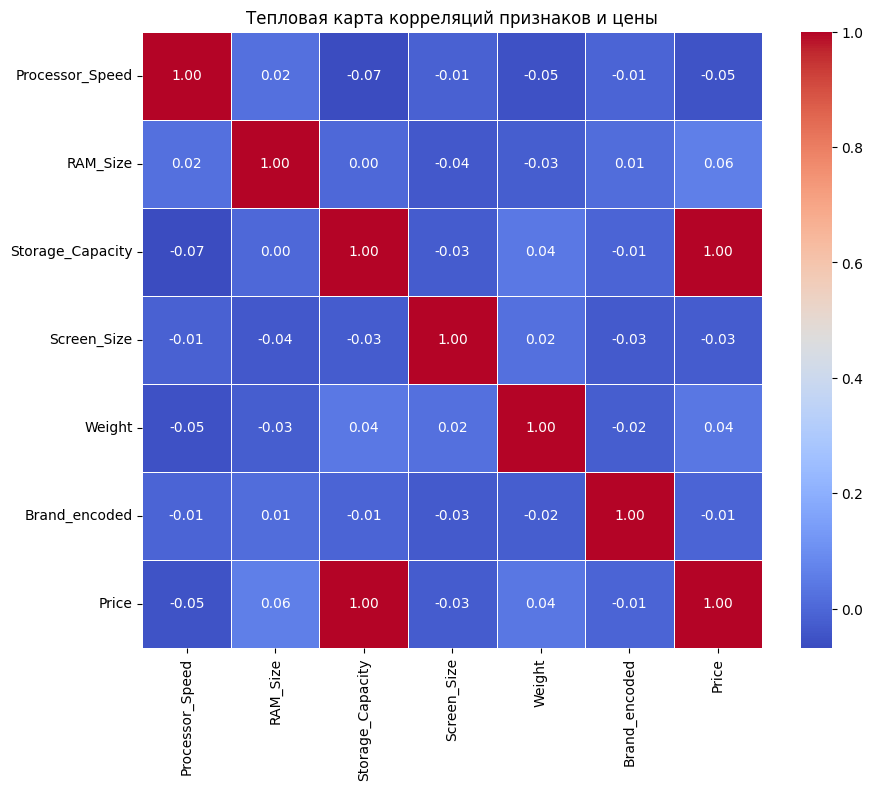

In [ ]:
# Построим тепловую матрицу корреляций (используем масштабированные данные + цену)
corr_matrix = df_scaled[numeric_cols + ['Price']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Тепловая карта корреляций признаков и цены')
plt.show()

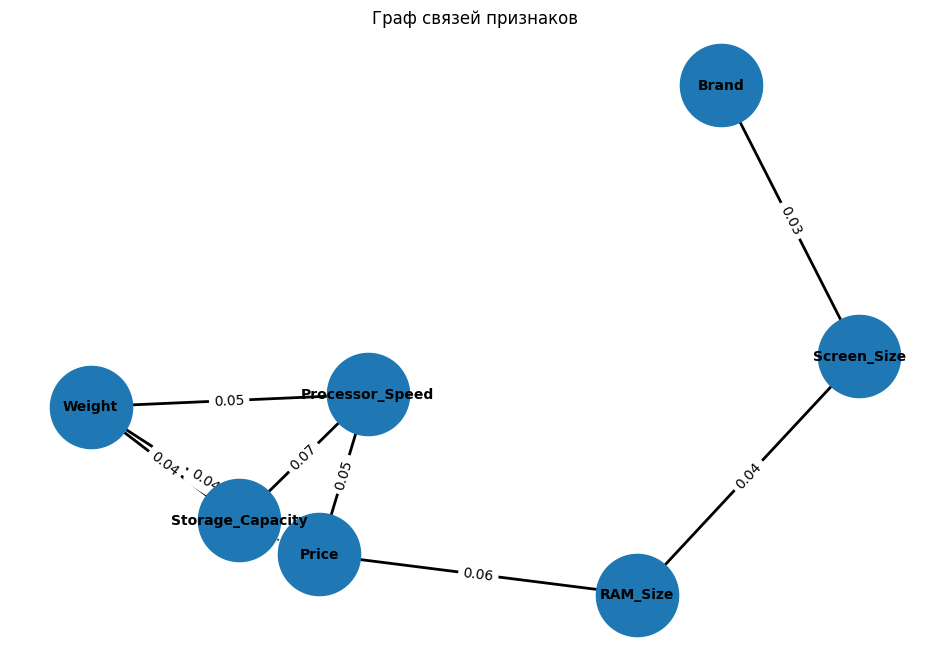

In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.preprocessing import LabelEncoder

# ---------------------------------------------------------
# Кодирование категориального признака
# ---------------------------------------------------------

encoder = LabelEncoder()

df['Brand'] = encoder.fit_transform(df['Brand'])

# ---------------------------------------------------------
# Корреляционная матрица
# ---------------------------------------------------------

corr_matrix = df.corr(numeric_only=True)

# ---------------------------------------------------------
# Создание графа
# ---------------------------------------------------------

G = nx.Graph()

# Добавление узлов

for column in corr_matrix.columns:
    G.add_node(column)

# ---------------------------------------------------------
# Добавление связей
# ---------------------------------------------------------

threshold = 0.03

for i in range(len(corr_matrix.columns)):

    for j in range(i + 1, len(corr_matrix.columns)):

        corr_value = corr_matrix.iloc[i, j]

        if abs(corr_value) > threshold:

            G.add_edge(
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                weight=round(abs(corr_value), 2)
            )

# ---------------------------------------------------------
# Визуализация
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(
    G,
    pos,
    node_size=3500
)

nx.draw_networkx_edges(
    G,
    pos,
    width=2
)

nx.draw_networkx_labels(
    G,
    pos,
    font_size=10,
    font_weight='bold'
)

edge_labels = nx.get_edge_attributes(G, 'weight')

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels
)

plt.title('Граф связей признаков')

plt.axis('off')

plt.show()


Feature Importance (DecisionTree max_depth=3):

            Feature  Feature_Importance
3  Storage_Capacity            0.996883
2          RAM_Size            0.003093
1   Processor_Speed            0.000024
0             Brand            0.000000
4       Screen_Size            0.000000
5            Weight            0.000000


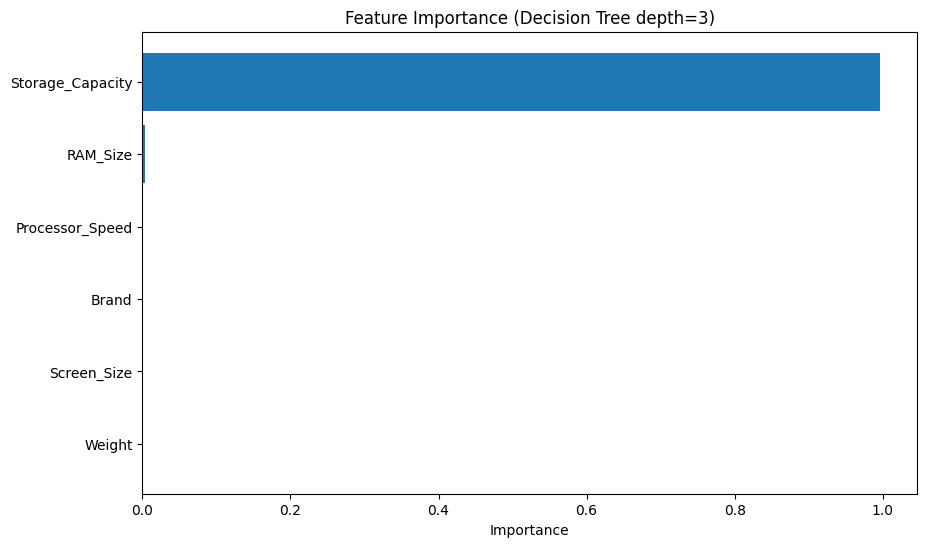

In [ ]:
# =========================================================
# ДОПОЛНИТЕЛЬНЫЙ БЛОК: Decision Tree + Feature Importance
# =========================================================

from sklearn.tree import DecisionTreeRegressor

X = df.drop('Price', axis=1)
y = df['Price']

X = X.copy()
if X['Brand'].dtype == 'object':
    le = LabelEncoder()
    X['Brand'] = le.fit_transform(X['Brand'])

# Обучаем самый простой decision tree
tree_simple = DecisionTreeRegressor(
    max_depth=3,
    random_state=42
)

tree_simple.fit(X, y)

# Получаем feature importance
feature_importance = tree_simple.feature_importances_

importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Feature_Importance': feature_importance
})

# Сортировка по убыванию важности
importance_df = importance_df.sort_values(
    by='Feature_Importance',
    ascending=False
)

print("\nFeature Importance (DecisionTree max_depth=3):\n")
print(importance_df)

# Визуализация
plt.figure(figsize=(10,6))
plt.barh(importance_df['Feature'], importance_df['Feature_Importance'])
plt.gca().invert_yaxis()
plt.title('Feature Importance (Decision Tree depth=3)')
plt.xlabel('Importance')
plt.show()